Proses ini hanya digunakan sebagai visual validasi untuk menentukan tebakan awal Secant

Rentang Pencarian: [-4.5, 4.5]
Ditemukan 2 akar (zeros):
  Akar ke-1: x = -2.224737 | f(x) = 2.01e-05
  Akar ke-2: x = 0.224737 | f(x) = 2.01e-05


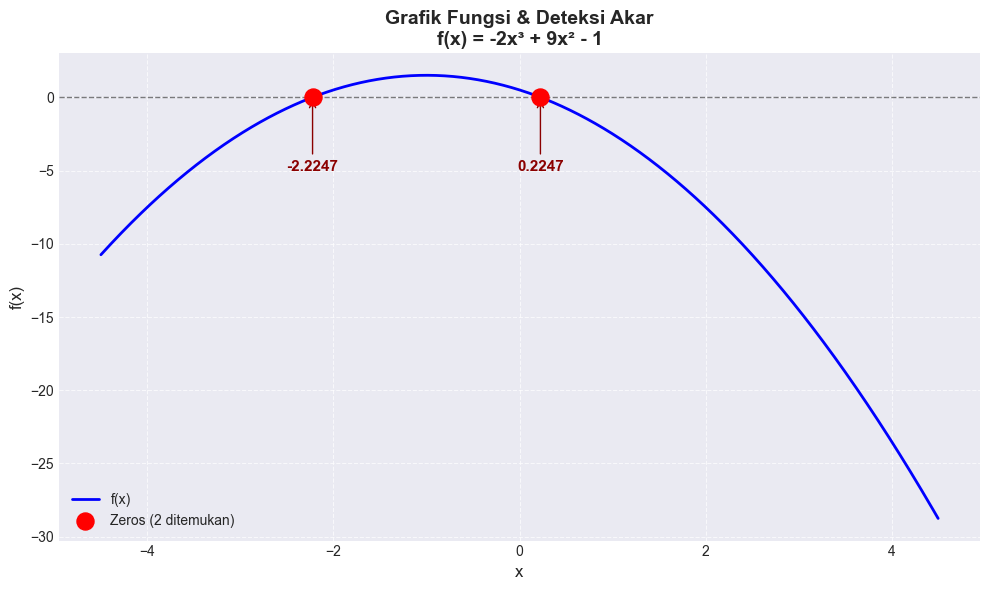

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Definisi Fungsi Non-Linear
def f(x):
    # Ubah rumus fungsi di bawah ini sesuai kebutuhan
    return - x**2 - 2*x +0.5

# Konfigurasi batas nilai x dan data_points
x_min = -4.50
x_max = 4.50
num_points = 1000  # Semakin tinggi, semakin halus plot & deteksi akar

# Generate data
x = np.linspace(x_min, x_max, num_points)
y = f(x)

# Algoritma Pencarian Akar (menggunakan library)
# Proses ini digunakan untuk pembanding saja
zeros_list = []

# Deteksi perubahan tanda (sign change)
# Proses inti dari Secant Method
sign_changes = np.where(np.diff(np.sign(y)))[0]

for i in sign_changes:
    x1, x2 = x[i], x[i+1]
    y1, y2 = y[i], y[i+1]

    # Hindari pembagian dengan nol jika y1 == y2
    if y2 - y1 != 0:
        # Interpolasi Linear untuk presisi
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)
        zeros_list.append(x_root)

# Hapus akar ganda (jika ada deteksi ganda)
unique_zeros = []
for z in zeros_list:
    if not any(abs(z - uz) < 1e-3 for uz in unique_zeros):
        unique_zeros.append(z)

# Konversi ke numpy array
zeros = np.array(unique_zeros)

# Visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Fungsi
ax.plot(x, y, label='f(x)', color='blue', linewidth=2)

# Plot Garis Y = 0
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

# Plot Titik Zeros
if len(zeros) > 0:
    zero_y = f(zeros)
    ax.scatter(zeros, zero_y, color='red', s=150, zorder=5, label=f'Zeros ({len(zeros)} ditemukan)')

    # Anotasi Nilai Akar
    for z in zeros:
        ax.annotate(f'{z:.4f}',
                    xy=(z, 0),
                    xytext=(z, f(z) - 5),
                    horizontalalignment='center',
                    fontsize=11,
                    color='darkred',
                    weight='bold',
                    arrowprops=dict(arrowstyle='->', color='darkred'))
else:
    print("Tidak ada akar yang ditemukan dalam rentang ini.")

# Dekorasi plot
ax.set_title(f'Grafik Fungsi & Deteksi Akar\nf(x) = -2x³ + 9x² - 1', fontsize=14, fontweight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.7)

print("Proses ini hanya digunakan sebagai visual validasi untuk menentukan tebakan awal Secant\n")
print("="*50)
print(f"Rentang Pencarian: [{x_min}, {x_max}]")
print("="*50)
if len(zeros) > 0:
    print(f"Ditemukan {len(zeros)} akar (zeros):")
    for i, z in enumerate(zeros, 1):
        print(f"  Akar ke-{i}: x = {z:.6f} | f(x) = {f(z):.2e}")
else:
    print("Tidak ada akar riil dalam rentang tersebut.")
print("="*50)

plt.tight_layout()
plt.show()

# Secant Method

Metode Secant adalah metode pencarian akar yang merupakan pengembangan dari Metode Newton-Raphson. Perbedaan utamanya adalah Secant Method **tidak membutuhkan turunan fungsi** secara eksplisit. Sebagai gantinya, turunan diaproksimasi menggunakan selisih hingga (*finite difference*) dari dua titik sebelumnya.

## Rumus Iterasi

$$x_{n+1} = x_n - f(x_n) \cdot \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$$

Di mana:
- $x_{n-1}$ dan $x_n$ = dua tebakan awal
- $f(x_{n-1})$ dan $f(x_n)$ = nilai fungsi pada kedua titik tersebut
- $x_{n+1}$ = aproksimasi akar berikutnya

## Metode Pencarian

Dalam tugas ini saya membuat dua metode pencarian:
- 1. Metode tolerance atau sesuai nilai absolute error (abs) tanpa memedulikan jumlah iterasi.
- 2. Metode dengan jumlah iterasi tanpa memedulikan berapa nilai tolerancenya atau nilai absolute errornya.

## Kelebihan & Keterbatasan

**Kelebihan:**
- Tidak memerlukan turunan fungsi secara eksplisit
- Konvergensi lebih cepat dibanding Bisection (orde ~1.618)

**Keterbatasan:**
- Membutuhkan dua tebakan awal
- Dapat divergen jika tebakan awal tidak dekat dengan akar
- Gagal jika $f(x_n) = f(x_{n-1})$ (pembagi nol)

In [33]:
def secant(x0, x1, tol=1e-6, max_iter=100, mode='tolerance'):
    """
    Metode Secant dengan 2 mode:
    - mode='tolerance'  -> berhenti saat error < tol
    - mode='iteration'  -> berhenti setelah max_iter iterasi

    Parameters
    ----------
    x0, x1  : float  — dua tebakan awal
    tol      : float  — toleransi error (mode='tolerance')
    max_iter : int    — jumlah iterasi maksimum (mode='iteration')
    mode     : str    — 'tolerance' atau 'iteration'

    Returns
    -------
    x2      : float — aproksimasi akar
    iterasi : int   — jumlah iterasi yang dilakukan
    """
    iterasi = 0
    x2 = x1

    print(f"{'Iterasi':<8} {'x0':<18} {'x1':<18} {'x2':<18} {'f(x2)':<18} {'Error':<15}")
    print("-" * 95)

    while True:
        iterasi += 1
        fx0 = f(x0)
        fx1 = f(x1)

        # Cek pembagi nol
        if abs(fx1 - fx0) < 1e-10:
            print("f(x1) - f(x0) mendekati nol — metode berhenti.")
            break

        # Rumus Secant
        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        fx2 = f(x2)
        error = abs(x2 - x1)

        print(f"{iterasi:<8} {x0:<18.8f} {x1:<18.8f} {x2:<18.8f} {fx2:<18.8f} {error:<15.2e}")

        if mode == 'tolerance' and error < tol:
            break
        elif mode == 'iteration' and iterasi >= max_iter:
            break

        # Update titik
        x0, x1 = x1, x2

    return x2, iterasi, error

In [34]:
# Mode 1: Berdasarkan toleransi
print("MODE 1 - Toleransi (tol = 1e-6)\n")
root1, iter1 = secant(x0=0.0, x1=1.0, tol=1e-6, mode='tolerance')
print(f"\nHasil:")
print(f"  Akar     : {root1:.10f}")
print(f"  Iterasi  : {iter1}")
print(f"  f(akar)  : {f(root1):.2e}")

MODE 1 - Toleransi (tol = 1e-6)

Iterasi  x0                 x1                 x2                 f(x2)              Error          
-----------------------------------------------------------------------------------------------
1        0.00000000         1.00000000         0.16666667         0.13888889         8.33e-01       
2        1.00000000         0.16666667         0.21052632         0.03462604         4.39e-02       
3        0.16666667         0.21052632         0.22509225         -0.00085102        1.46e-02       
4        0.21052632         0.22509225         0.22474284         0.00000497         3.49e-04       
5        0.22509225         0.22474284         0.22474487         0.00000000         2.03e-06       
6        0.22474284         0.22474487         0.22474487         -0.00000000        2.88e-10       


ValueError: too many values to unpack (expected 2)

In [ ]:
# Mode 2: Berdasarkan jumlah iterasi
print("MODE 2 - Iterasi Tetap (max_iter = 10)\n")
root2, iter2 = secant(x0=0.0, x1=1.0, max_iter=10, mode='iteration')
print(f"\nHasil:")
print(f"  Akar     : {root2:.10f}")
print(f"  Iterasi  : {iter2}")
print(f"  f(akar)  : {f(root2):.2e}")

MODE 2 - Iterasi Tetap (max_iter = 10)

Iterasi  x0                 x1                 x2                 f(x2)              Error          
-----------------------------------------------------------------------------------------------
1        0.00000000         1.00000000         0.16666667         0.13888889         8.33e-01       
2        1.00000000         0.16666667         0.21052632         0.03462604         4.39e-02       
3        0.16666667         0.21052632         0.22509225         -0.00085102        1.46e-02       
4        0.21052632         0.22509225         0.22474284         0.00000497         3.49e-04       
5        0.22509225         0.22474284         0.22474487         0.00000000         2.03e-06       
6        0.22474284         0.22474487         0.22474487         -0.00000000        2.88e-10       
7        0.22474487         0.22474487         0.22474487         0.00000000         2.22e-16       
f(x1) - f(x0) mendekati nol — metode berhenti.

Hasil:
 